# Ch13 模型建立與驗證(Model Development and Verification)

**對應原書**:Chapter 13
**軟體替代**:ModelQ + 實機 DSA 比對流程 → 「未知受控體」chirp 量測 + 低頻擬合 + 模型/量測 Bode 疊圖

## 學習目標
走一遍書中的建模驗證流程:
1. 對「未知的真實受控體」做 DSA 頻率響應量測。
2. 從低頻段擬合**剛體模型**(總慣量)。
3. 疊圖比較:剛體模型在哪個頻段失效?失效處透露什麼物理?

這裡的「真實受控體」用 two-mass 模型 + 量測雜訊扮演(參數假裝未知),
實機版流程見 `hardware/` 與第 19 章。

In [1]:
import sys, pathlib
sys.path.append(str(pathlib.Path('..').resolve()))
import numpy as np
import matplotlib.pyplot as plt
import control as ct
from common.control_helpers import (first_order, second_order, integrator, inertia,
                                    pi, pid, closed_loop, margins, step_metrics, bandwidth_hz)
from common.sim import (DiscretePID, MotorPlant, DCMotorPlant, TwoMassPlant,
                        Backlash, EncoderModel, Delay, saturate, quantize, coulomb)
from common.dsa import chirp_excitation, prbs_excitation, measure_frf, frf_of_system
from common.plots import bode_compare
np.set_printoptions(precision=4, suppress=True)

In [2]:
# --- 「未知」受控體(假裝我們不知道參數)---
SECRET = dict(Jm=1e-3, Jl=1e-3, ks=100.0, cs=0.01)
fs = 10000.0
dt = 1 / fs

rig = TwoMassPlant(**SECRET, dt=dt)
tt, u = chirp_excitation(f0=2, f1=300, duration=20, fs=fs, amplitude=0.5)
rng = np.random.default_rng(7)
noise = rng.normal(0, 0.02, len(u))

y = np.empty_like(u)
for k, uk in enumerate(u):
    wm, _ = rig.step(uk)
    y[k] = wm + noise[k]                 # 量到的馬達速度(含雜訊)

meas = measure_frf(u, y, fs)
good = (meas['coherence'] > 0.9) & (meas['f_hz'] > 1.5) & (meas['f_hz'] < 300)
mf = {k: v[good] for k, v in meas.items()}
print(f'有效量測點:{good.sum()},頻率範圍 {mf["f_hz"][0]:.1f} ~ {mf["f_hz"][-1]:.1f} Hz')

有效量測點:111,頻率範圍 2.4 ~ 288.1 Hz


## 步驟 2:低頻擬合剛體模型

剛體慣量的頻率響應 $|H| = \dfrac{1}{J_{tot}\,\omega}$,
取 2~10 Hz 段(遠低於任何共振)反推 $J_{tot}$。

擬合 J_tot = 2.000 mkg·m²(真值 2.000,誤差 0.0%)


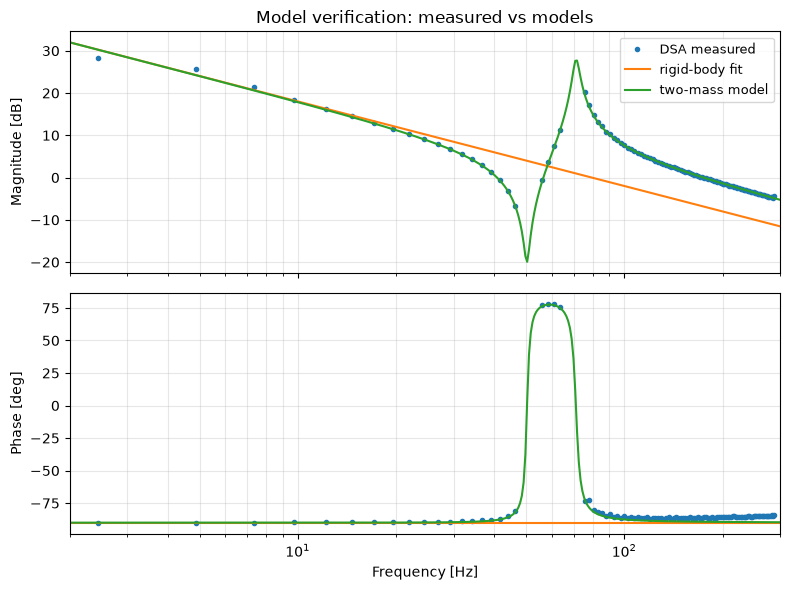

In [3]:
lo = (mf['f_hz'] >= 2) & (mf['f_hz'] <= 10)
w_lo = 2 * np.pi * mf['f_hz'][lo]
J_est = float(np.mean(1.0 / (np.abs(mf['H'][lo]) * w_lo)))
J_true = SECRET['Jm'] + SECRET['Jl']
print(f'擬合 J_tot = {J_est*1000:.3f} mkg·m²(真值 {J_true*1000:.3f},誤差 {abs(J_est-J_true)/J_true*100:.1f}%)')

P_rigid = ct.tf([1], [J_est, 0])

# 完整 two-mass 解析模型(「事後」用真值建,對照量測)
Jm, Jl, ks, cs = SECRET['Jm'], SECRET['Jl'], SECRET['ks'], SECRET['cs']
num = [Jl, cs, ks]
den = [Jm * Jl, (Jm + Jl) * cs, (Jm + Jl) * ks, 0.0]
P_2mass = ct.tf(num, den)

fig, (axm, axp) = bode_compare([
    ('DSA measured', mf, '.'),
    ('rigid-body fit', P_rigid),
    ('two-mass model', P_2mass),
], f_hz=np.logspace(np.log10(2), np.log10(300), 400),
   title='Model verification: measured vs models')
axm.set_xlim(2, 300)
plt.show()

## 步驟 3:讀圖

- **2~30 Hz**:剛體模型與量測重合 → 總慣量正確。
- **50 Hz 附近**:量測掉出一個谷(antiresonance)→ 剛體模型解釋不了。
- **70 Hz 附近**:量測衝出一個峰(resonance)→ 這是**機構柔性**的簽名(第 16 章主角)。

> 書中的鐵律:**模型與量測不合的地方,就是還沒建進模型的物理。**

In [4]:
# 從量測資料自動找共振峰 / 反共振谷
band = (mf['f_hz'] > 30) & (mf['f_hz'] < 150)
fb, mb = mf['f_hz'][band], mf['mag_db'][band]
f_res_meas = float(fb[np.argmax(mb)])
f_anti_meas = float(fb[np.argmin(mb)])

tm_check = TwoMassPlant(**SECRET)
print(f'量測共振 {f_res_meas:.1f} Hz(理論 {tm_check.resonance_hz:.1f} Hz)')
print(f'量測反共振 {f_anti_meas:.1f} Hz(理論 {tm_check.antiresonance_hz:.1f} Hz)')

# 剛體模型 vs 量測的偏差(在共振處應該很大)
rig_at = frf_of_system(P_rigid, [f_res_meas])['mag_db'][0]
meas_at = float(mf['mag_db'][band][np.argmax(mb)])
print(f'共振處剛體模型誤差:{meas_at - rig_at:.1f} dB')

量測共振 75.7 Hz(理論 71.2 Hz)
量測反共振 46.4 Hz(理論 50.3 Hz)
共振處剛體模型誤差:19.8 dB


In [5]:
# ✅ 驗證
assert abs(J_est - J_true) / J_true < 0.15                     # 慣量擬合 < 15%
assert abs(f_res_meas - tm_check.resonance_hz) / tm_check.resonance_hz < 0.1
assert abs(f_anti_meas - tm_check.antiresonance_hz) / tm_check.antiresonance_hz < 0.1
assert (meas_at - rig_at) > 10                                 # 共振處剛體模型差 >10 dB
# 低頻段 two-mass 模型與量測吻合(±2 dB)
ana = frf_of_system(P_2mass, mf['f_hz'][lo])
assert np.max(np.abs(ana['mag_db'] - mf['mag_db'][lo])) < 2
print('Ch13 驗證通過 ✅')

Ch13 驗證通過 ✅


## 練習
1. 把雜訊放大 10 倍,哪些頻段的 coherence 先崩?擬合還可信嗎?
2. 只用 0.2 Nm 的激發振幅重量一次,比較品質(訊噪比 vs 激發能量)。
3. 對 two-mass 的**負載端速度** wl 做同樣量測,Bode 形狀有什麼不同?(提示:沒有反共振谷)
4. 寫一個最小平方擬合,直接從量測 FRF 擬合出 ks 與 Jm/Jl 分配,對照真值。